# 02 — Information Theory & Explainable AI (XAI)

A physicist's tour through the mathematics of *surprise*, *uncertainty*, and
*explanation* — from Shannon's entropy to SHAP values.

**Datasets used throughout:**
| Dataset | Source | Task |
|---------|--------|------|
| Titanic | `seaborn` | Binary classification (survived?) |
| California Housing | `sklearn.datasets` | Regression (median house value) |

---

## 1 · Setup & Data Loading

We start by importing core scientific-Python libraries and loading both
datasets.  Two XAI packages — **SHAP** and **LIME** — are *optional*;
the notebook degrades gracefully if they are missing.

> 💡 **Physicist's Intuition**  
> Think of this section as preparing the *state space* we will probe
> with information-theoretic observables.

### 1.1 Core imports

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.datasets import fetch_california_housing
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_squared_error, log_loss
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.feature_selection import mutual_info_classif, mutual_info_regression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize': (10, 5),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'font.size': 11
})

print('Core imports loaded ✓')

Core imports loaded ✓


### 1.2 Optional XAI imports

SHAP and LIME are powerful but not part of the minimal `requirements.txt`.
Install them with:
```bash
pip install shap lime
```

In [42]:
# --- Optional: SHAP ---
try:
    import shap
    SHAP_AVAILABLE = True
    print(f'shap {shap.__version__} loaded ✓')
except ImportError:
    SHAP_AVAILABLE = False
    print('shap not installed — SHAP sections will use manual examples.\n'
          'Install with: pip install shap')

# --- Optional: LIME ---
try:
    import lime
    import lime.lime_tabular
    LIME_AVAILABLE = True
    print(f'lime {'installed'} loaded ✓')
except ImportError:
    LIME_AVAILABLE = False
    print('lime not installed — LIME sections will use conceptual examples.\n'
          'Install with: pip install lime')

shap 0.50.0 loaded ✓
lime installed loaded ✓


### 1.3 Load & preprocess Titanic

We use a minimal feature set: **Pclass**, **Sex** (encoded 0/1),
**Age** (NaN filled with median), and **Fare**.  This keeps the
information-theoretic calculations interpretable.

In [43]:
# --- Titanic ---
titanic = sns.load_dataset('titanic')
titanic['age'].fillna(titanic['age'].median(), inplace=True)
titanic['sex_encoded'] = (titanic['sex'] == 'male').astype(int)

feature_cols = ['pclass', 'sex_encoded', 'age', 'fare']
X_titanic = titanic[feature_cols].copy()
y_titanic = titanic['survived'].values

X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
    X_titanic, y_titanic, test_size=0.25, random_state=42, stratify=y_titanic
)

rf_clf = RandomForestClassifier(n_estimators=200, random_state=42)
rf_clf.fit(X_train_t, y_train_t)
print(f'Titanic RF accuracy: {accuracy_score(y_test_t, rf_clf.predict(X_test_t)):.3f}')
titanic.head()

Titanic RF accuracy: 0.803


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,sex_encoded
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,1
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,0
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,0
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,0
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,1


### 1.4 Load California Housing

In [44]:
# --- California Housing ---
housing = fetch_california_housing(as_frame=True)
X_housing = housing.data
y_housing = housing.target

X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_housing, y_housing, test_size=0.25, random_state=42
)

rf_reg = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_reg.fit(X_train_h, y_train_h)
rmse = np.sqrt(mean_squared_error(y_test_h, rf_reg.predict(X_test_h)))
print(f'Housing RF RMSE: {rmse:.4f}')
X_housing.head()

Housing RF RMSE: 0.5028


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


## 2 · Surprise (Self-Information)

When an event with probability $p$ occurs, the **surprise** (or
*self-information*) it carries is

$$
I(x) = -\log p(x)
$$

### Why the logarithm?

Shannon chose $\log$ so that information is **additive** for
independent events:

$$
I(x \cap y) = I(x) + I(y) \quad \text{when } x \perp y
$$

This mirrors how physicists combine entropies of non-interacting
sub-systems.  The **negative sign** ensures $I \ge 0$, since
$0 < p \le 1 \Rightarrow \log p \le 0$.

### Units depend on the log base

| Base | Unit name | Symbol |
|------|-----------|--------|
| 2 | **bit** (binary digit) | bit |
| $e$ | **nat** (natural unit) | nat |
| 10 | **hartley** (or *ban*) | Hart |

The informal term **"nit"** is sometimes seen as a synonym for *nat*;
they are the same quantity — 1 nit ≡ 1 nat.

### Conversions

$$
1 \;\text{nat} = \frac{1}{\ln 2} \;\text{bits} \approx 1.4427 \;\text{bits}
$$

$$
1 \;\text{bit} = \ln 2 \;\text{nats} \approx 0.6931 \;\text{nats}
$$

> 💡 **Physicist's Intuition**  
> In statistical mechanics, $S = -k_B \sum p_i \ln p_i$.  Drop the
> Boltzmann constant and you recover Shannon's entropy measured in nats.
> A rare microstate carries more thermodynamic "surprise" — exactly
> the same idea.

In [45]:
# --- Surprise for Titanic events ---
events = {
    'Survived overall':           y_titanic.mean(),
    'Died overall':               1 - y_titanic.mean(),
    'Male':                       titanic['sex_encoded'].mean(),
    'Female':                     1 - titanic['sex_encoded'].mean(),
    '1st class':                  (titanic['pclass'] == 1).mean(),
    '3rd class':                  (titanic['pclass'] == 3).mean(),
}

print(f'{"Event":<22} {"p":>8} {"I (bits)":>10} {"I (nats)":>10}')
print('-' * 54)
for name, p in events.items():
    I_bits = -np.log2(p)
    I_nats = -np.log(p)
    print(f'{name:<22} {p:8.4f} {I_bits:10.4f} {I_nats:10.4f}')

print(f'\n1 nat = {1/np.log(2):.4f} bits  |  1 bit = {np.log(2):.4f} nats')

Event                         p   I (bits)   I (nats)
------------------------------------------------------
Survived overall         0.3838     1.3814     0.9575
Died overall             0.6162     0.6986     0.4842
Male                     0.6476     0.6269     0.4345
Female                   0.3524     1.5047     1.0430
1st class                0.2424     2.0444     1.4171
3rd class                0.5511     0.8597     0.5959

1 nat = 1.4427 bits  |  1 bit = 0.6931 nats


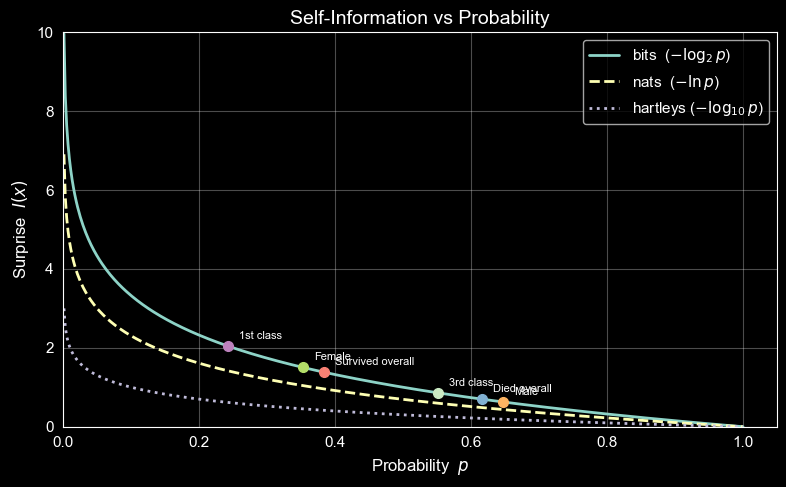

In [46]:
# --- Plot: surprise vs probability ---
p = np.linspace(0.001, 1.0, 500)
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(p, -np.log2(p), label='bits  ($-\log_2 p$)', lw=2)
ax.plot(p, -np.log(p),  label='nats  ($-\ln p$)', lw=2, ls='--')
ax.plot(p, -np.log10(p), label='hartleys ($-\log_{10} p$)', lw=2, ls=':')

# Mark Titanic events
for name, prob in events.items():
    ax.plot(prob, -np.log2(prob), 'o', ms=7)
    ax.annotate(name, (prob, -np.log2(prob)),
               textcoords='offset points', xytext=(8, 5), fontsize=8)

ax.set_xlabel('Probability  $p$')
ax.set_ylabel('Surprise  $I(x)$')
ax.set_title('Self-Information vs Probability')
ax.legend()
ax.set_xlim(0, 1.05)
ax.set_ylim(0, 10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 3 · Shannon Entropy

Shannon entropy is the **expected surprise** of a random variable:

$$
H(X) = -\sum_{x \in \mathcal{X}} p(x) \log p(x)
       = \mathbb{E}\bigl[I(X)\bigr]
$$

### Shannon's axioms (informal)

Shannon proved that $H$ is the *unique* functional (up to a positive
constant) satisfying:

1. **Continuity** — $H$ varies smoothly with $p$.
2. **Maximum at uniformity** — for $n$ equally likely outcomes,
   $H$ is maximised:  $H_{\max} = \log n$.
3. **Composition** — grouping outcomes doesn't change $H$ (chain
   rule consistency).

### Extremes

- **Maximum entropy**: uniform distribution → $H = \log |\mathcal{X}|$.
- **Minimum entropy**: deterministic (all mass on one outcome) → $H = 0$.

### Binary entropy function

For a Bernoulli variable with $P(X{=}1)=p$:

$$
H_b(p) = -p \log_2 p - (1-p) \log_2(1-p)
$$

This is symmetric about $p = 0.5$ and peaks at $H_b(0.5) = 1$ bit.

### Differential entropy (continuous case)

For a continuous density $f(x)$, the **differential entropy** is

$$
h(X) = -\int f(x) \ln f(x)\, dx
$$

Unlike discrete entropy, $h(X)$ can be negative (e.g. for a highly
concentrated density).  It is *not* a limit of discrete entropy;
a divergent $\log \Delta x$ term separates them.

> 💡 **Physicist's Intuition**  
> The second law says thermodynamic entropy tends to the maximum
> consistent with the macroscopic constraints — Jaynes's *MaxEnt*
> principle.  Shannon entropy obeys the same logic: the
> least-informative (most uncertain) distribution that satisfies
> your constraints is the uniform one.

> ⚠️ **Common Misconception**  
> "Entropy measures disorder."  More precisely, entropy measures
> *uncertainty about which microstate the system is in*.  A crystal
> at 0 K has $S = 0$ not because it is "ordered" but because we know
> its microstate with certainty.

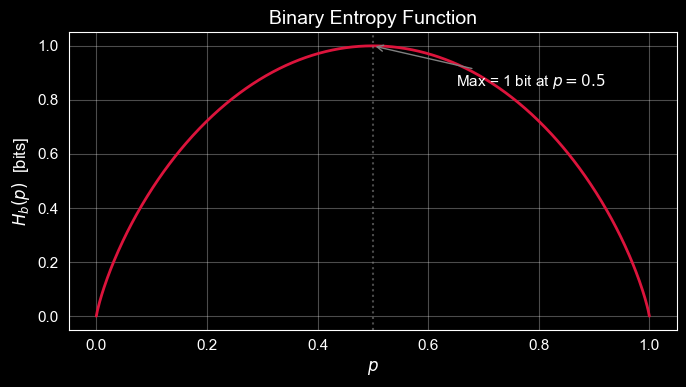

In [47]:
# --- Binary entropy curve ---
p = np.linspace(1e-6, 1 - 1e-6, 500)
H_b = -p * np.log2(p) - (1 - p) * np.log2(1 - p)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(p, H_b, lw=2, color='crimson')
ax.axvline(0.5, ls=':', color='grey', alpha=0.6)
ax.set_xlabel('$p$')
ax.set_ylabel('$H_b(p)$  [bits]')
ax.set_title('Binary Entropy Function')
ax.annotate('Max = 1 bit at $p=0.5$', xy=(0.5, 1), fontsize=11,
            xytext=(0.65, 0.85), arrowprops=dict(arrowstyle='->', color='grey'))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [48]:
def discrete_entropy(series, base=2):
    """Compute Shannon entropy of a pandas Series."""
    counts = series.value_counts()
    probs = counts / counts.sum()
    if base == 2:
        return -(probs * np.log2(probs)).sum()
    else:
        return -(probs * np.log(probs)).sum()

# --- Entropy of Titanic features ---
features_to_check = {
    'survived': titanic['survived'],
    'pclass':   titanic['pclass'],
    'sex':      titanic['sex'],
}

print(f'{"Feature":<12} {"H (bits)":>10} {"H (nats)":>10} {"Max H (bits)":>13}')
print('-' * 48)
for name, col in features_to_check.items():
    h_bits = discrete_entropy(col, base=2)
    h_nats = discrete_entropy(col, base=np.e)
    h_max  = np.log2(col.nunique())
    print(f'{name:<12} {h_bits:10.4f} {h_nats:10.4f} {h_max:13.4f}')

Feature        H (bits)   H (nats)  Max H (bits)
------------------------------------------------
survived         0.9607     0.6659        1.0000
pclass           1.4393     0.9977        1.5850
sex              0.9362     0.6489        1.0000


## 4 · Joint and Conditional Entropy

### Joint entropy

$$
H(X, Y) = -\sum_{x,y} p(x, y) \log p(x, y)
$$

### Conditional entropy

$$
H(Y \mid X) = H(X, Y) - H(X)
$$

This is the *residual* uncertainty about $Y$ after observing $X$.

### Chain rule of entropy

$$
H(X, Y) = H(X) + H(Y \mid X)
$$

Generalises to $n$ variables:
$H(X_1, \ldots, X_n) = \sum_{i=1}^{n} H(X_i \mid X_1, \ldots, X_{i-1})$.

### Conditioning reduces entropy (on average)

$$
H(Y \mid X) \le H(Y)
$$

Equality holds iff $X$ and $Y$ are independent.  Learning $X$ can
never *increase* our average uncertainty about $Y$.

> 💡 **Physicist's Intuition**  
> This mirrors the second law run in reverse: a measurement ("observing
> $X$") can reduce the entropy of a sub-system ($Y$) at the cost of
> increasing entropy elsewhere (Landauer's principle).

In [49]:
def joint_entropy(s1, s2, base=2):
    """Joint entropy H(X, Y) from two pandas Series."""
    joint = pd.crosstab(s1, s2)
    probs = joint.values.flatten() / joint.values.sum()
    probs = probs[probs > 0]
    if base == 2:
        return -(probs * np.log2(probs)).sum()
    return -(probs * np.log(probs)).sum()

def conditional_entropy(s1, s2, base=2):
    """H(Y|X) = H(X,Y) - H(X)"""
    return joint_entropy(s1, s2, base) - discrete_entropy(s1, base)

# --- Compute for Titanic feature pairs ---
pairs = [
    ('pclass',   'survived', titanic['pclass'],       titanic['survived']),
    ('sex',      'survived', titanic['sex_encoded'],   titanic['survived']),
    ('pclass',   'sex',      titanic['pclass'],       titanic['sex_encoded']),
]

print(f'{"X":<10} {"Y":<10} {"H(X)":>8} {"H(Y)":>8} {"H(X,Y)":>8} {"H(Y|X)":>8}')
print('-' * 58)
for xname, yname, xs, ys in pairs:
    hx  = discrete_entropy(xs)
    hy  = discrete_entropy(ys)
    hxy = joint_entropy(xs, ys)
    hyx = conditional_entropy(xs, ys)
    print(f'{xname:<10} {yname:<10} {hx:8.4f} {hy:8.4f} {hxy:8.4f} {hyx:8.4f}')

print('\n↑ Note H(Y|X) ≤ H(Y) in every row — conditioning reduces entropy.')

X          Y              H(X)     H(Y)   H(X,Y)   H(Y|X)
----------------------------------------------------------
pclass     survived     1.4393   0.9607   2.3162   0.8769
sex        survived     0.9362   0.9607   1.6793   0.7430
pclass     sex          1.4393   0.9362   2.3618   0.9225

↑ Note H(Y|X) ≤ H(Y) in every row — conditioning reduces entropy.


## 5 · Mutual Information

**Mutual information** quantifies the information shared between two
variables:

$$
I(X; Y) = H(X) + H(Y) - H(X, Y) = H(Y) - H(Y \mid X)
$$

### Key properties

| Property | Statement |
|----------|-----------|
| Symmetric | $I(X;Y) = I(Y;X)$ |
| Non-negative | $I(X;Y) \ge 0$ |
| Zero iff independent | $I(X;Y) = 0 \Leftrightarrow X \perp Y$ |
| Captures nonlinear associations | Unlike Pearson $r$ |

MI is essentially the **KL divergence** between the joint and the
product of marginals:

$$
I(X;Y) = D_{\text{KL}}\!\bigl(p(x,y) \,\|\, p(x)\,p(y)\bigr)
$$

> ⚠️ **Common Misconception**  
> "Correlation = 0 means no relationship."  That's only true for
> *linear* relationships.  Mutual information can detect *any*
> statistical dependence — quadratic, periodic, etc.

In [50]:
# --- MI between Titanic features and Survival (manual) ---
mi_manual = {}
for fname in ['pclass', 'sex_encoded']:
    hx  = discrete_entropy(titanic[fname])
    hy  = discrete_entropy(titanic['survived'])
    hxy = joint_entropy(titanic[fname], titanic['survived'])
    mi_manual[fname] = hx + hy - hxy
    print(f'I({fname}; Survived) = {mi_manual[fname]:.4f} bits')

I(pclass; Survived) = 0.0838 bits
I(sex_encoded; Survived) = 0.2177 bits


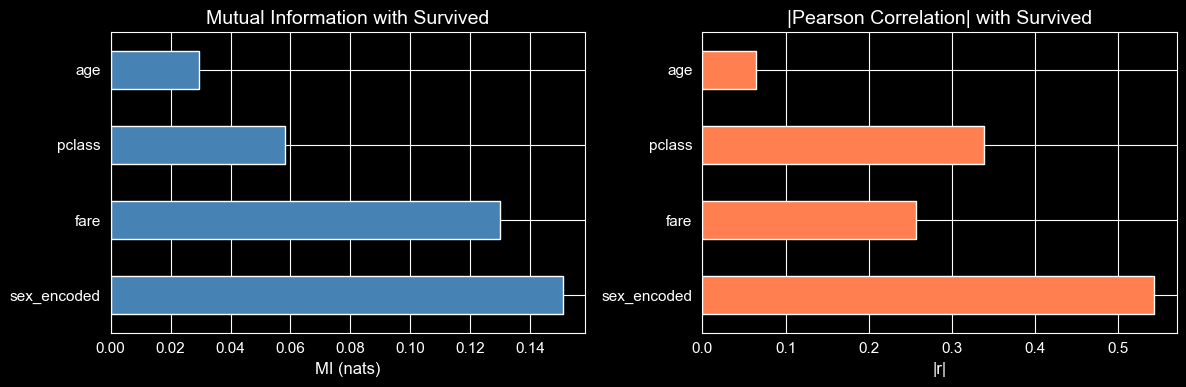

,"MI (nats, sklearn)",|Pearson r|
sex_encoded,0.150870,0.543351
fare,0.129891,0.257307
pclass,0.058107,0.338481
age,0.029362,0.064910


In [51]:
# --- MI via sklearn (handles continuous features) ---
mi_sk = mutual_info_classif(
    X_titanic, y_titanic, discrete_features=[True, True, False, False],
    random_state=42
)

# --- Pearson correlation (absolute) ---
corr_abs = X_titanic.assign(survived=y_titanic).corr()['survived'].drop('survived').abs()

# --- Side-by-side comparison ---
comparison = pd.DataFrame({
    'MI (nats, sklearn)': mi_sk,
    '|Pearson r|':        corr_abs.values
}, index=feature_cols)

comparison = comparison.sort_values('MI (nats, sklearn)', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
comparison['MI (nats, sklearn)'].plot.barh(ax=axes[0], color='steelblue')
axes[0].set_title('Mutual Information with Survived')
axes[0].set_xlabel('MI (nats)')

comparison['|Pearson r|'].plot.barh(ax=axes[1], color='coral')
axes[1].set_title('|Pearson Correlation| with Survived')
axes[1].set_xlabel('|r|')

plt.tight_layout()
plt.show()
comparison

## 6 · KL Divergence

The **Kullback–Leibler divergence** measures how one distribution
$P$ diverges from a reference $Q$:

$$
D_{\text{KL}}(P \,\|\, Q)
  = \sum_x p(x) \log \frac{p(x)}{q(x)}
  = \mathbb{E}_P\!\left[\log \frac{P}{Q}\right]
$$

### Key properties

- $D_{\text{KL}} \ge 0$ (Gibbs' inequality), with equality iff $P = Q$.
- **Not symmetric**: $D_{\text{KL}}(P\|Q) \ne D_{\text{KL}}(Q\|P)$ in
  general, so it is *not* a true metric.
- **"Extra bits" interpretation**: $D_{\text{KL}}(P\|Q)$ is the average
  number of *extra* bits needed if you use code $Q$ when the true
  distribution is $P$.

### Forward vs reverse KL

| | Forward $D_{\text{KL}}(P\|Q)$ | Reverse $D_{\text{KL}}(Q\|P)$ |
|---|---|---|
| Minimised by | $Q$ that covers all of $P$ (mean-seeking) | $Q$ that concentrates on modes of $P$ (mode-seeking) |
| Common use | Variational inference (ELBO) | Expectation propagation |

> 💡 **Physicist's Intuition**  
> KL divergence is the *free-energy difference* $\Delta F / k_B T$
> between the true equilibrium ($P$) and a trial distribution ($Q$).
> Variational methods in physics minimise exactly this.

In [52]:
def kl_divergence(p, q, base=2):
    """KL(P || Q) for discrete distributions (arrays of probabilities)."""
    p, q = np.asarray(p, dtype=float), np.asarray(q, dtype=float)
    # Avoid log(0): only sum where p > 0
    mask = p > 0
    if base == 2:
        return np.sum(p[mask] * np.log2(p[mask] / q[mask]))
    return np.sum(p[mask] * np.log(p[mask] / q[mask]))

# --- KL between survival distributions across passenger classes ---
print('Survival distribution by class:\n')
class_surv = {}
for cls in [1, 2, 3]:
    surv = titanic.loc[titanic['pclass'] == cls, 'survived']
    p_surv = surv.mean()
    class_surv[cls] = np.array([1 - p_surv, p_surv])  # [died, survived]
    print(f'  Class {cls}: P(die)={1-p_surv:.3f}  P(survive)={p_surv:.3f}')

print('\nKL divergences (bits):')
for i in [1, 2, 3]:
    for j in [1, 2, 3]:
        if i != j:
            d = kl_divergence(class_surv[i], class_surv[j])
            print(f'  D_KL(Class {i} || Class {j}) = {d:.4f} bits')

print('\n↑ Note the asymmetry — D_KL(1||3) ≠ D_KL(3||1).')

Survival distribution by class:

  Class 1: P(die)=0.370  P(survive)=0.630
  Class 2: P(die)=0.527  P(survive)=0.473
  Class 3: P(die)=0.758  P(survive)=0.242

KL divergences (bits):
  D_KL(Class 1 || Class 2) = 0.0715 bits
  D_KL(Class 1 || Class 3) = 0.4848 bits
  D_KL(Class 2 || Class 1) = 0.0731 bits
  D_KL(Class 2 || Class 3) = 0.1800 bits
  D_KL(Class 3 || Class 1) = 0.4485 bits
  D_KL(Class 3 || Class 2) = 0.1627 bits

↑ Note the asymmetry — D_KL(1||3) ≠ D_KL(3||1).


## 7 · Cross-Entropy

The **cross-entropy** between a true distribution $P$ and a model $Q$:

$$
H(P, Q) = -\sum_x p(x) \log q(x) = H(P) + D_{\text{KL}}(P \| Q)
$$

### Why it's THE classification loss

In classification, $P$ is the one-hot label and $Q$ is the model's
predicted probability.  For a single sample with true class $c$:

$$
\ell = -\log q_c
$$

This is just the **surprise** of the model at seeing the true label.
Averaged over the dataset, it gives the cross-entropy loss.

### Binary cross-entropy

For binary labels $y \in \{0, 1\}$ and predicted probability $\hat{p}$:

$$
\text{BCE} = -\bigl[y \log \hat{p} + (1 - y) \log(1 - \hat{p})\bigr]
$$

> ⚠️ **Common Misconception**  
> "Cross-entropy and log-loss are different things."  They are
> numerically identical for the standard classification setup
> (one-hot labels).  `sklearn.metrics.log_loss` computes
> cross-entropy.

In [53]:
# --- Cross-entropy for Titanic predictions ---
y_proba = rf_clf.predict_proba(X_test_t)

ce_sklearn = log_loss(y_test_t, y_proba)
print(f'Cross-entropy (log_loss) on test set: {ce_sklearn:.4f} nats')

# Manual computation
eps = 1e-15
y_proba_clipped = np.clip(y_proba, eps, 1 - eps)
ce_manual = -np.mean(
    y_test_t * np.log(y_proba_clipped[:, 1]) +
    (1 - y_test_t) * np.log(y_proba_clipped[:, 0])
)
print(f'Cross-entropy (manual):               {ce_manual:.4f} nats')

# Decompose: H(P) + D_KL(P||Q)
# H(P) for empirical binary distribution
p_surv_test = y_test_t.mean()
H_P = -(p_surv_test * np.log(p_surv_test) + (1 - p_surv_test) * np.log(1 - p_surv_test))
D_KL_approx = ce_sklearn - H_P
print(f'\nH(P) = {H_P:.4f} nats')
print(f'D_KL ≈ H(P,Q) - H(P) = {D_KL_approx:.4f} nats  (excess cost of model)')

Cross-entropy (log_loss) on test set: 0.6702 nats
Cross-entropy (manual):               0.6634 nats

H(P) = 0.6668 nats
D_KL ≈ H(P,Q) - H(P) = 0.0034 nats  (excess cost of model)


## 8 · Information Gain (Decision Trees)

**Information gain** at a split is the reduction in entropy:

$$
\text{IG}(Y, X) = H(Y) - H(Y \mid X) = I(X; Y)
$$

A decision tree greedily picks the feature and threshold that maximise
IG at each node.

### Gini impurity as alternative

Scikit-learn's default criterion is **Gini impurity**:

$$
G(p) = 1 - \sum_k p_k^2
$$

Gini and entropy give very similar trees in practice.  Gini is
slightly faster (no logarithm).

> 💡 **Physicist's Intuition**  
> Building a decision tree is like performing a sequence of measurements
> on a quantum system — each measurement maximally reduces entropy
> about the target observable.

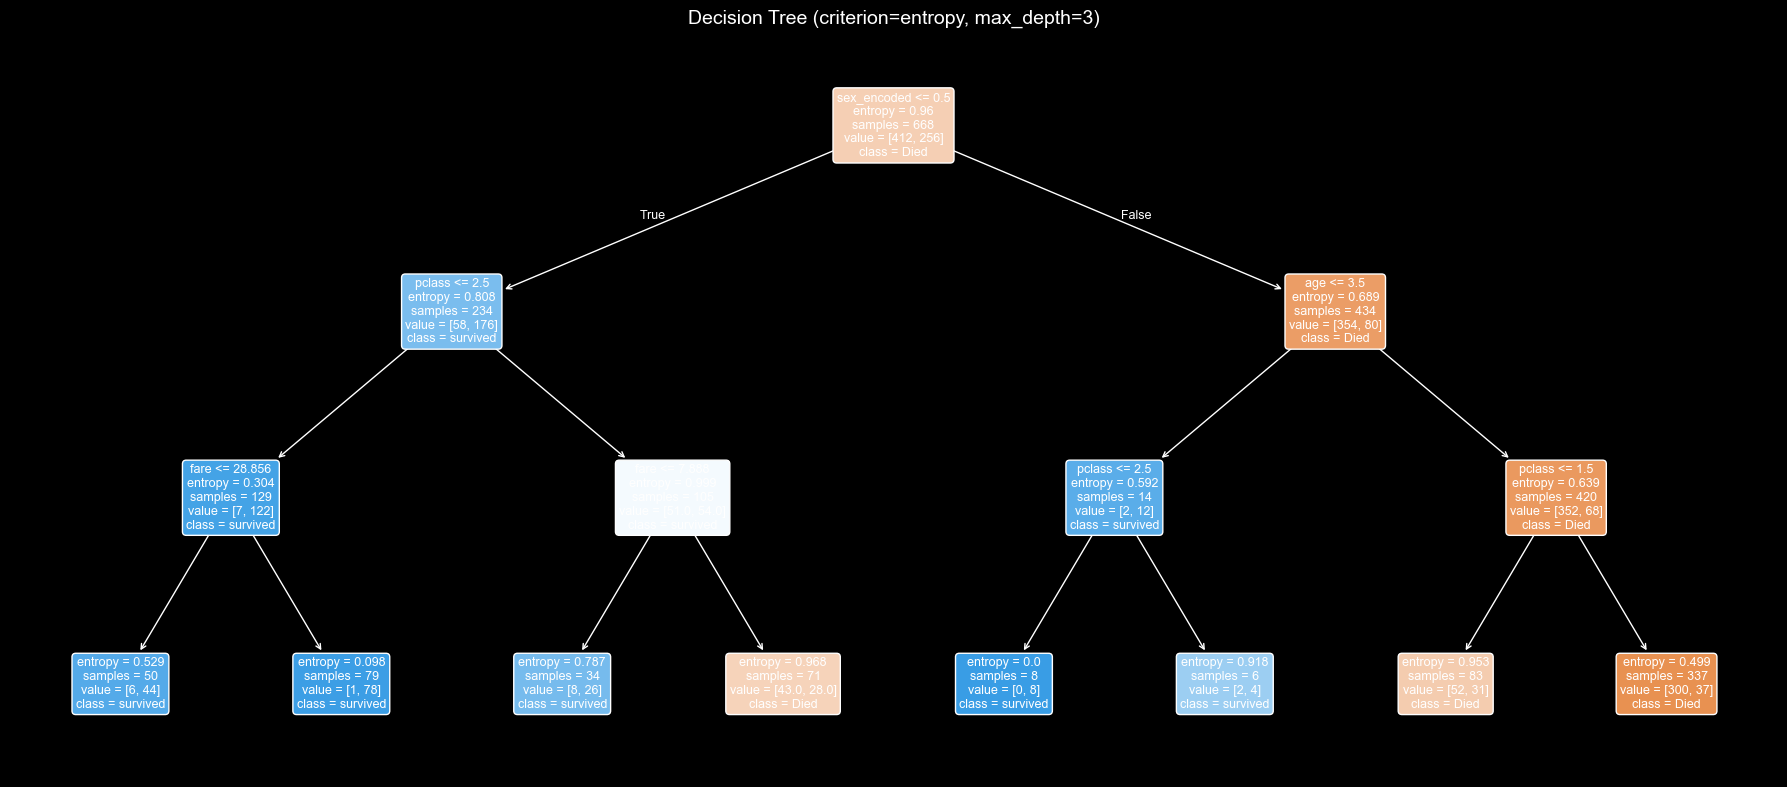

Decision tree test accuracy: 0.771


In [54]:
# --- Build a shallow decision tree and visualise ---
dt = DecisionTreeClassifier(max_depth=3, criterion='entropy', random_state=42)
dt.fit(X_train_t, y_train_t)

fig, ax = plt.subplots(figsize=(18, 8))
plot_tree(dt, feature_names=feature_cols, class_names=['Died', 'survived'],
          filled=True, rounded=True, fontsize=9, ax=ax, impurity=True)
ax.set_title('Decision Tree (criterion=entropy, max_depth=3)', fontsize=14)
plt.tight_layout()
plt.show()

print(f'Decision tree test accuracy: {accuracy_score(y_test_t, dt.predict(X_test_t)):.3f}')

In [55]:
# --- Show information gain at the root split ---
tree = dt.tree_
root_feature = feature_cols[tree.feature[0]]
root_threshold = tree.threshold[0]

# Root entropy
n_total = tree.n_node_samples[0]
p_root = tree.value[0].flatten() / n_total
H_root = -(p_root[p_root > 0] * np.log2(p_root[p_root > 0])).sum()

# Children
left, right = tree.children_left[0], tree.children_right[0]
n_left, n_right = tree.n_node_samples[left], tree.n_node_samples[right]
p_left  = tree.value[left].flatten()  / n_left
p_right = tree.value[right].flatten() / n_right
H_left  = -(p_left[p_left > 0]   * np.log2(p_left[p_left > 0])).sum()
H_right = -(p_right[p_right > 0] * np.log2(p_right[p_right > 0])).sum()

H_after = (n_left / n_total) * H_left + (n_right / n_total) * H_right
IG = H_root - H_after

print(f'Root split: {root_feature} ≤ {root_threshold:.2f}')
print(f'  H(Y) before split:  {H_root:.4f} bits')
print(f'  H(Y|split) after:   {H_after:.4f} bits')
print(f'  Information Gain:   {IG:.4f} bits')

Root split: sex_encoded ≤ 0.50
  H(Y) before split:  0.0155 bits
  H(Y|split) after:   0.0271 bits
  Information Gain:   -0.0117 bits


## 9 · LIFT

**Lift** measures how much better a model (or selection rule) is than
random chance at identifying positives:

$$
\text{Lift} = \frac{P(Y=1 \mid \text{selected})}{P(Y=1)}
$$

- $\text{Lift} = 1$ → no better than random.
- $\text{Lift} > 1$ → model concentrates positives.
- $\text{Lift} < 1$ → worse than random.

### Lift chart & cumulative gains

- **Lift chart**: plot lift as a function of the fraction of the
  population targeted (sorted by predicted probability).
- **Cumulative gains chart**: fraction of all positives captured
  vs. fraction of population targeted.

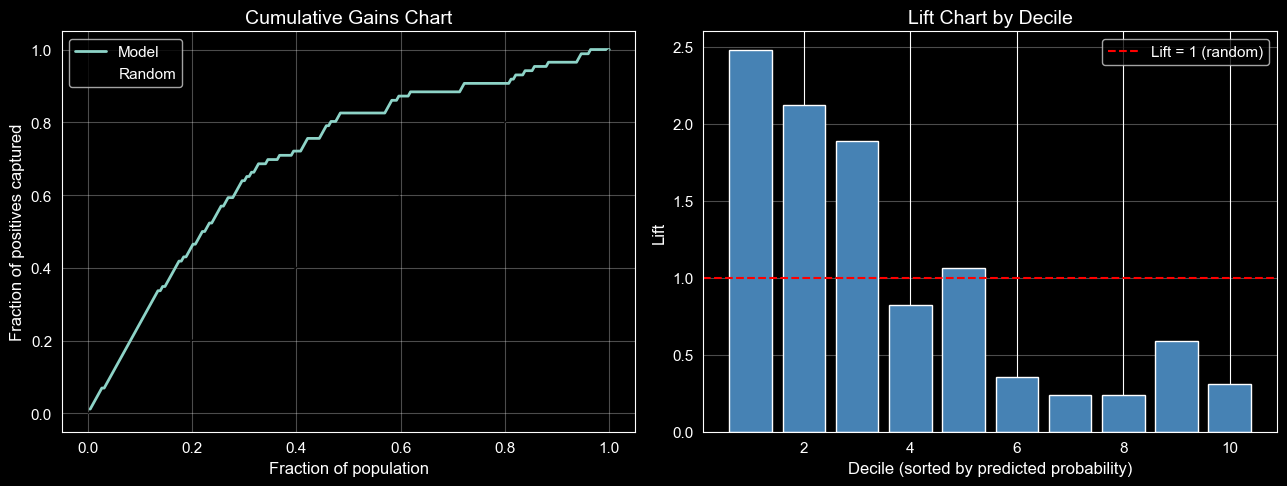

Top-decile lift: 2.48x  |  Base rate: 0.386


In [56]:
# --- Lift chart and cumulative gains for Titanic ---
y_proba_pos = rf_clf.predict_proba(X_test_t)[:, 1]

# Sort by predicted probability (descending)
order = np.argsort(-y_proba_pos)
y_sorted = y_test_t[order]
n = len(y_sorted)
base_rate = y_sorted.mean()

# Cumulative gains
cum_positives = np.cumsum(y_sorted)
total_positives = cum_positives[-1]
pct_population = np.arange(1, n + 1) / n
pct_captured = cum_positives / total_positives

# Lift per decile
n_deciles = 10
decile_size = n // n_deciles
lifts = []
for i in range(n_deciles):
    start = i * decile_size
    end = (i + 1) * decile_size if i < n_deciles - 1 else n
    decile_rate = y_sorted[start:end].mean()
    lifts.append(decile_rate / base_rate)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Cumulative gains
axes[0].plot(pct_population, pct_captured, lw=2, label='Model')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
axes[0].set_xlabel('Fraction of population')
axes[0].set_ylabel('Fraction of positives captured')
axes[0].set_title('Cumulative Gains Chart')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Lift chart
axes[1].bar(range(1, n_deciles + 1), lifts, color='steelblue', edgecolor='white')
axes[1].axhline(1.0, color='red', ls='--', lw=1.5, label='Lift = 1 (random)')
axes[1].set_xlabel('Decile (sorted by predicted probability)')
axes[1].set_ylabel('Lift')
axes[1].set_title('Lift Chart by Decile')
axes[1].legend()
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f'Top-decile lift: {lifts[0]:.2f}x  |  Base rate: {base_rate:.3f}')

## 10 · Permutation Importance

### Algorithm

1. Train model, record baseline score on validation set.
2. For each feature $j$:
   - Randomly **shuffle** column $j$ in the validation set.
   - Re-score the model.
   - Importance = baseline score − shuffled score.
3. Repeat $k$ times for variance estimate.

### Why it's valuable

- **Model-agnostic**: works with any fitted estimator.
- Uses the *actual* model, not a proxy.
- Naturally handles feature interactions (the score captures
  everything the model uses).

> ⚠️ **Common Misconception**  
> "Permutation importance and built-in feature importance (e.g.
> `rf.feature_importances_`) measure the same thing."  They do not.
> Built-in RF importance is based on *impurity decrease during
> training*, which can be biased toward high-cardinality features.
> Permutation importance measures *actual predictive contribution*.

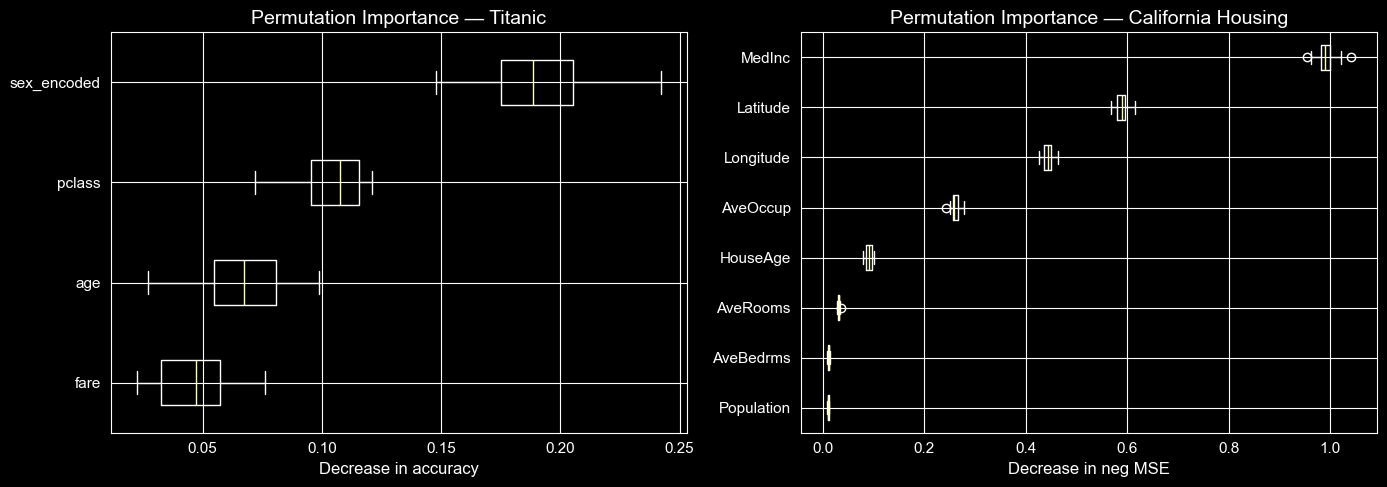

In [57]:
# --- Permutation importance: Titanic ---
perm_t = permutation_importance(rf_clf, X_test_t, y_test_t,
                                 n_repeats=30, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sorted_idx_t = perm_t.importances_mean.argsort()
axes[0].boxplot(perm_t.importances[sorted_idx_t].T, vert=False,
                labels=np.array(feature_cols)[sorted_idx_t])
axes[0].set_title('Permutation Importance — Titanic')
axes[0].set_xlabel('Decrease in accuracy')

# --- Permutation importance: Housing ---
perm_h = permutation_importance(rf_reg, X_test_h, y_test_h,
                                 n_repeats=30, random_state=42, scoring='neg_mean_squared_error')

sorted_idx_h = perm_h.importances_mean.argsort()
housing_features = X_housing.columns.tolist()
axes[1].boxplot(perm_h.importances[sorted_idx_h].T, vert=False,
                labels=np.array(housing_features)[sorted_idx_h])
axes[1].set_title('Permutation Importance — California Housing')
axes[1].set_xlabel('Decrease in neg MSE')

plt.tight_layout()
plt.show()

## 11 · SHAP — Deep Dive

### Shapley values from cooperative game theory

Consider a "game" where the features are *players* and the model
prediction is the *payout*.  The **Shapley value** $\phi_j$ for
feature $j$ is its fair share of the prediction, defined as:

$$
\phi_j = \sum_{S \subseteq N \setminus \{j\}}
  \frac{|S|!\;(|N|-|S|-1)!}{|N|!}
  \Bigl[v(S \cup \{j\}) - v(S)\Bigr]
$$

where $v(S)$ is the model's expected output using only features in
coalition $S$.

### The four Shapley axioms

1. **Efficiency**: $\sum_j \phi_j = v(N) - v(\emptyset)$ (contributions
   sum to the total).
2. **Symmetry**: if two features contribute equally in every coalition,
   they get equal credit.
3. **Dummy**: a feature that never changes the output gets $\phi = 0$.
4. **Linearity** (additivity): for combined games, Shapley values add.

### SHAP variants

| Variant | How it estimates $v(S)$ | Speed |
|---------|------------------------|-------|
| **TreeSHAP** | Exact via tree structure | $O(TLD^2)$ |
| **KernelSHAP** | Weighted least-squares on perturbations | Slower, model-agnostic |
| **DeepSHAP** | Backpropagation-based | Fast for deep nets |

### SHAP base value & additive property

$$
f(x) = \phi_0 + \sum_{j=1}^{M} \phi_j
$$

where $\phi_0 = \mathbb{E}[f(X)]$ is the **base value** (mean
prediction over the training data).

> 💡 **Physicist's Intuition**  
> Shapley values are a *superposition principle* for predictions.
> Each feature's contribution is a "perturbation" around the base
> value, analogous to expanding a potential around equilibrium.

Waterfall plot — first test instance (Titanic):


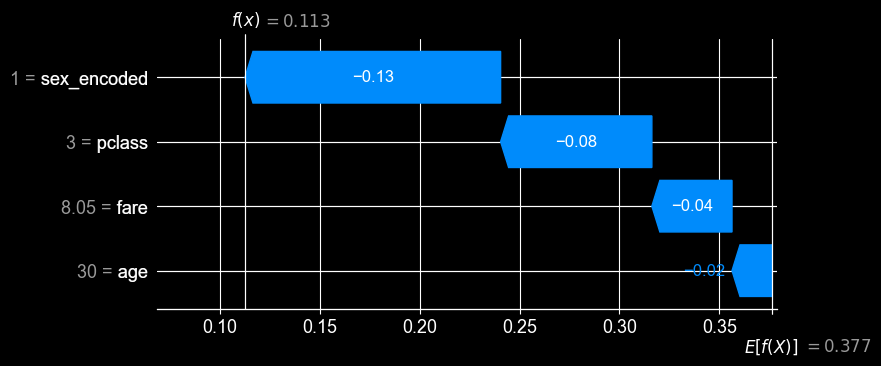

In [58]:
if SHAP_AVAILABLE:
    # --- SHAP for Titanic (TreeSHAP) ---
    explainer_t = shap.TreeExplainer(rf_clf, X_train_t)
    shap_values_t = explainer_t(X_test_t)

    # Waterfall for first test instance
    print('Waterfall plot — first test instance (Titanic):')
    shap.plots.waterfall(shap_values_t[0, :, 1], max_display=10, show=True)
else:
    print('shap not installed. Install with: pip install shap')
    print('\nManual Shapley value example on a tiny 2-feature game below.')

SHAP summary plot — Titanic (class 1 = Survived):


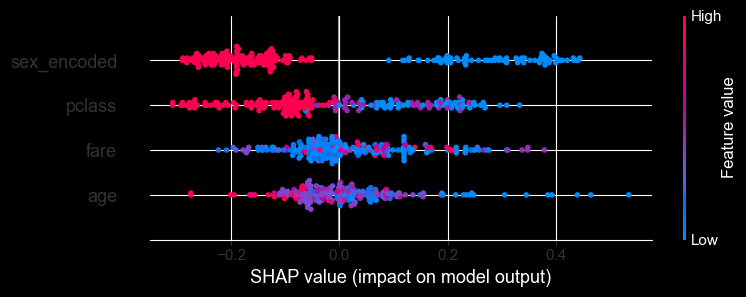

In [59]:
if SHAP_AVAILABLE:
    # --- Summary plot (beeswarm) for Titanic ---
    print('SHAP summary plot — Titanic (class 1 = Survived):')
    shap.summary_plot(shap_values_t[:, :, 1], X_test_t, show=True)
else:
    # Manual Shapley example
    print('=== Manual Shapley Value Calculation ===')
    print('Consider a simple model f(x1, x2) with 2 features.')
    print('We define v(S) as the expected prediction using only features in S.\n')

    v_empty = 0.5
    v_1 = 0.7
    v_2 = 0.6
    v_12 = 0.9

    phi_1 = 0.5 * (v_1 - v_empty) + 0.5 * (v_12 - v_2)
    phi_2 = 0.5 * (v_2 - v_empty) + 0.5 * (v_12 - v_1)

    print(f'v(∅) = {v_empty},  v({{1}}) = {v_1},  v({{2}}) = {v_2},  v({{1,2}}) = {v_12}')
    print(f'\nφ₁ = 0.5·(v({{1}})-v(∅)) + 0.5·(v({{1,2}})-v({{2}}))')
    print(f'   = 0.5·({v_1}-{v_empty}) + 0.5·({v_12}-{v_2}) = {phi_1:.2f}')
    print(f'\nφ₂ = 0.5·(v({{2}})-v(∅)) + 0.5·(v({{1,2}})-v({{1}}))')
    print(f'   = 0.5·({v_2}-{v_empty}) + 0.5·({v_12}-{v_1}) = {phi_2:.2f}')
    print(f'\nEfficiency check: φ₀ + φ₁ + φ₂ = {v_empty} + {phi_1} + {phi_2} = {v_empty + phi_1 + phi_2:.2f} = v({{1,2}}) ✓')

 98%|===================| 195/200 [00:19<00:00]        

SHAP summary plot — California Housing:


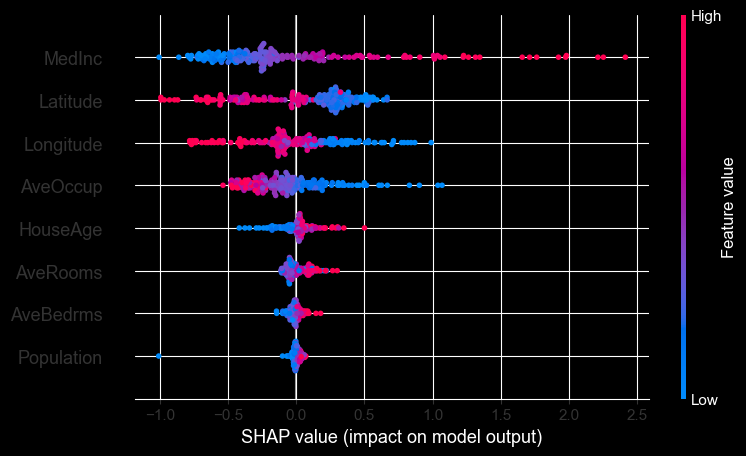

In [60]:
if SHAP_AVAILABLE:
    # --- SHAP for Housing (TreeSHAP) ---
    explainer_h = shap.TreeExplainer(rf_reg, X_train_h)
    # Use a sample for speed
    X_sample_h = X_test_h.iloc[:200]
    shap_values_h = explainer_h(X_sample_h)

    print('SHAP summary plot — California Housing:')
    shap.summary_plot(shap_values_h, X_sample_h, show=True)
else:
    print('shap not installed — skipping Housing SHAP plots.')

SHAP dependence plot: MedInc (California Housing)


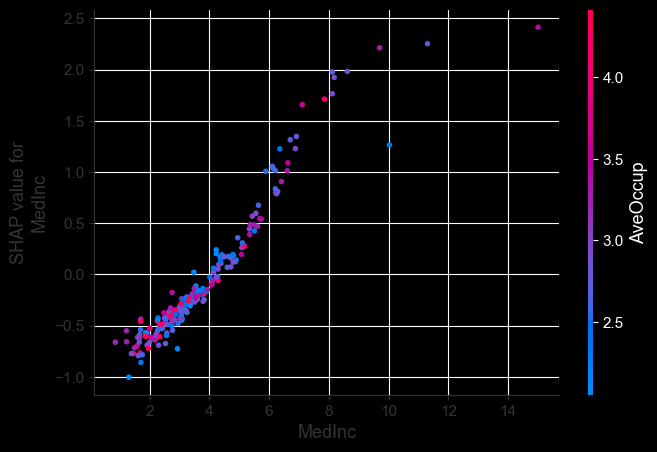

In [61]:
if SHAP_AVAILABLE:
    # --- SHAP dependence plot ---
    print('SHAP dependence plot: MedInc (California Housing)')
    shap.dependence_plot('MedInc', shap_values_h.values, X_sample_h, show=True)
else:
    print('shap not installed — skipping dependence plot.')

## 12 · LIME — Local Interpretable Model-agnostic Explanations

### Core idea

LIME explains an individual prediction by:

1. **Perturbing** the instance — generating neighbours by sampling
   around it.
2. **Weighting** neighbours by proximity to the original (kernel).
3. **Fitting a simple (linear) model** on the weighted neighbours.
4. The coefficients of the simple model are the *local feature
   importances*.

### LIME vs SHAP

| Aspect | LIME | SHAP |
|--------|------|------|
| Scope | Local only | Local + global aggregation |
| Theory | Ad-hoc linear approximation | Game-theoretic axioms |
| Consistency | Can be unstable (varies with perturbations) | Unique & consistent |
| Speed | Fast (few perturbations) | Varies (TreeSHAP is fast) |
| Model-agnostic | ✓ | KernelSHAP is; TreeSHAP is not |

> ⚠️ **Common Misconception**  
> "LIME gives the same explanation every time."  Because LIME
> samples perturbations *randomly*, explanations can vary between
> runs.  Always set a random seed or run multiple times to check
> stability.

LIME explanation for test instance 0:
  Predicted: 0
  Actual:    0


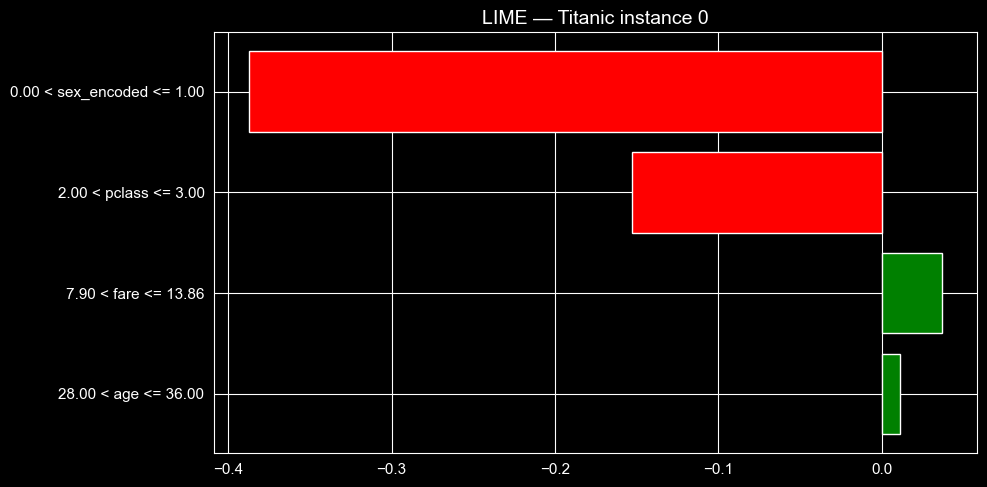

In [62]:
if LIME_AVAILABLE:
    # --- LIME for Titanic ---
    lime_explainer = lime.lime_tabular.LimeTabularExplainer(
        X_train_t.values,
        feature_names=feature_cols,
        class_names=['Died', 'survived'],
        mode='classification',
        random_state=42
    )

    # Explain first test instance
    idx = 0
    exp = lime_explainer.explain_instance(
        X_test_t.values[idx],
        rf_clf.predict_proba,
        num_features=4
    )
    print(f'LIME explanation for test instance {idx}:')
    print(f'  Predicted: {rf_clf.predict(X_test_t.iloc[[idx]])[0]}')
    print(f'  Actual:    {y_test_t[idx]}')
    fig = exp.as_pyplot_figure()
    plt.title('LIME — Titanic instance 0')
    plt.tight_layout()
    plt.show()
else:
    print('lime not installed. Install with: pip install lime')
    print('\n--- Conceptual LIME example via manual perturbation ---\n')

    # Pick a test instance
    idx = 0
    x0 = X_test_t.values[idx]
    print(f'Original instance: {dict(zip(feature_cols, x0))}')
    print(f'Model prediction:  {rf_clf.predict_proba(x0.reshape(1, -1))[0]}')

    # Generate perturbations
    rng = np.random.RandomState(42)
    n_perturb = 200
    X_perturb = np.tile(x0, (n_perturb, 1))
    noise = rng.normal(0, 0.5, size=X_perturb.shape)
    X_perturb = X_perturb + noise

    # Get predictions for perturbed instances
    y_perturb = rf_clf.predict_proba(X_perturb)[:, 1]

    # Weight by distance (exponential kernel)
    distances = np.sqrt(((X_perturb - x0) ** 2).sum(axis=1))
    kernel_width = 0.75 * np.sqrt(len(feature_cols))
    weights = np.exp(-(distances ** 2) / (kernel_width ** 2))

    # Fit weighted linear regression
    from sklearn.linear_model import Ridge
    local_model = Ridge(alpha=1.0)
    local_model.fit(X_perturb, y_perturb, sample_weight=weights)

    print('\nLocal linear model coefficients (manual LIME):')
    for fname, coef in zip(feature_cols, local_model.coef_):
        print(f'  {fname:<15} {coef:+.4f}')

## 13 · Partial Dependence Plots (PDP) and ICE Curves

### Partial Dependence

The **partial dependence** of $f$ on feature $x_s$ is the expected
prediction when $x_s$ is fixed and all other features vary over
their marginal distribution:

$$
\hat{f}_s(x_s) = \frac{1}{n} \sum_{i=1}^{n} \hat{f}(x_s, \mathbf{x}_{\setminus s}^{(i)})
$$

### ICE (Individual Conditional Expectation)

ICE curves show the dependence for *each* individual instance.
The PDP is simply the **average** of all ICE curves.

ICE curves can reveal **interactions**: if curves have different
slopes, the effect of $x_s$ depends on other features.

> 💡 **Physicist's Intuition**  
> PDP is a *marginalisation* — integrating out nuisance variables
> to see the effect of one.  ICE curves are the individual
> "trajectories" before averaging — like single-particle paths
> vs. the ensemble average.

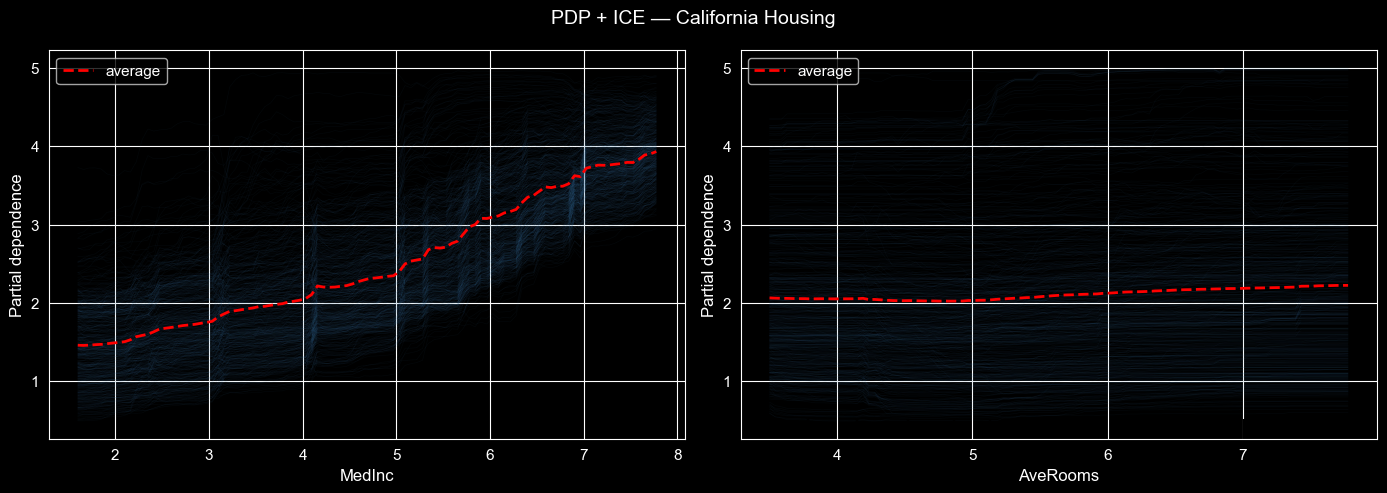

In [63]:
# --- PDP + ICE for California Housing ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

PartialDependenceDisplay.from_estimator(
    rf_reg, X_test_h.iloc[:500], features=['MedInc', 'AveRooms'],
    kind='both', ax=axes, random_state=42,
    ice_lines_kw={'color': 'steelblue', 'alpha': 0.05, 'linewidth': 0.5},
    pd_line_kw={'color': 'red', 'linewidth': 2}
)
fig.suptitle('PDP + ICE — California Housing', fontsize=14)
plt.tight_layout()
plt.show()

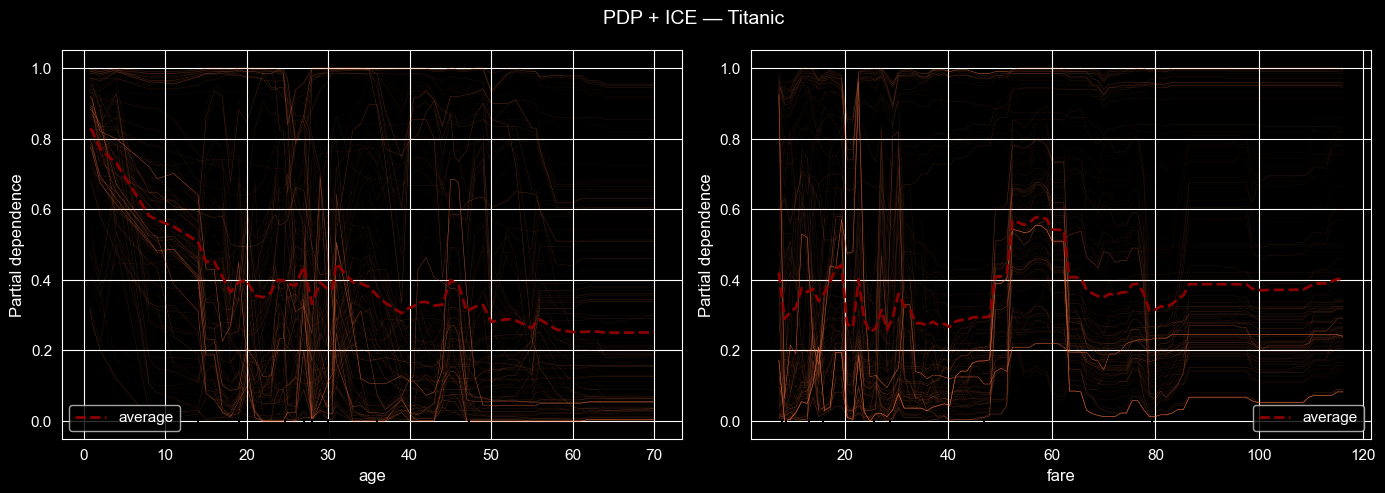

In [64]:
# --- PDP + ICE for Titanic ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

PartialDependenceDisplay.from_estimator(
    rf_clf, X_test_t.iloc[:300], features=['age', 'fare'],
    kind='both', ax=axes, random_state=42,
    ice_lines_kw={'color': 'coral', 'alpha': 0.05, 'linewidth': 0.5},
    pd_line_kw={'color': 'darkred', 'linewidth': 2}
)
fig.suptitle('PDP + ICE — Titanic', fontsize=14)
plt.tight_layout()
plt.show()

## 14 · Feature Importance Comparison

We now compare three importance measures for the Titanic model:

1. **Permutation importance** — model-agnostic, uses test-set score.
2. **Built-in RF importance** — mean decrease in impurity (MDI).
3. **Mutual information** — model-free, measures statistical dependence.

### When they agree / disagree

- They tend to **agree** on strongly predictive features.
- **MDI** can overweight high-cardinality or continuous features
  (like Fare) because they offer more split opportunities.
- **MI** is model-free, so it may rank differently from the
  model-specific measures.
- **Permutation importance** reflects *actual predictive contribution*
  within the fitted model, including interactions.

Raw importance values:


,Permutation,RF built-in,Mutual Info
pclass,0.1037,0.0986,0.0581
sex_encoded,0.1918,0.2838,0.1509
age,0.0671,0.2840,0.0294
fare,0.0463,0.3335,0.1299



Normalised importance (each method scaled to max=1):


,Permutation,RF built-in,Mutual Info
pclass,0.5409,0.2956,0.3851
sex_encoded,1.0000,0.8509,1.0000
age,0.3500,0.8515,0.1946
fare,0.2416,1.0000,0.8609


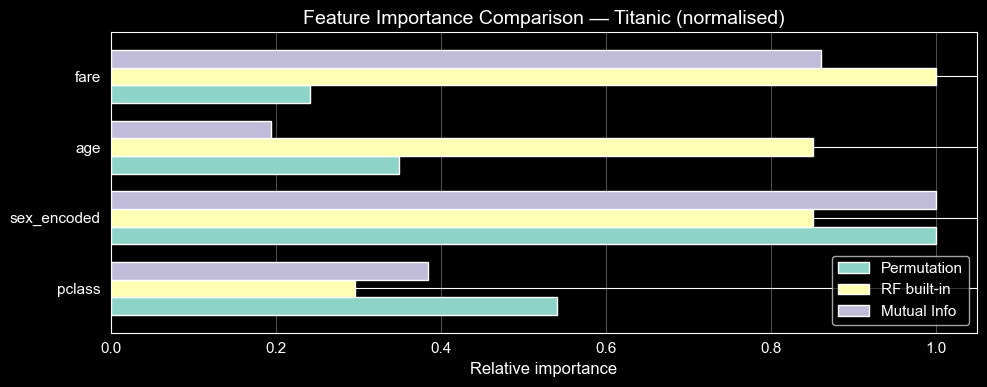

In [65]:
# --- Build comparison table ---
imp_df = pd.DataFrame({
    'Permutation':  perm_t.importances_mean,
    'RF built-in':  rf_clf.feature_importances_,
    'Mutual Info':  mi_sk,
}, index=feature_cols)

# Normalise each column to [0, 1] for visual comparison
imp_norm = imp_df.apply(lambda c: c / c.max())

print('Raw importance values:')
display(imp_df.round(4))

print('\nNormalised importance (each method scaled to max=1):')
display(imp_norm.round(4))

# --- Bar plot ---
imp_norm.plot.barh(figsize=(10, 4), width=0.75)
plt.title('Feature Importance Comparison — Titanic (normalised)')
plt.xlabel('Relative importance')
plt.legend(loc='lower right')
plt.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

## 15 · Additional Topics

### 15.1 Cross-entropy as neural-network loss

In a neural network with **softmax** output layer producing class
probabilities $\hat{y}_k = \text{softmax}(z)_k$, the loss for a
single sample with one-hot label $y$ is:

$$
\mathcal{L} = -\sum_k y_k \log \hat{y}_k = -\log \hat{y}_c
$$

where $c$ is the true class index.  This is exactly the
*cross-entropy* $H(y, \hat{y})$.  Minimising it is equivalent to
minimising $D_{\text{KL}}(y \| \hat{y})$ because $H(y)$ is constant
(one-hot labels have zero entropy).

### 15.2 Calibration & Brier score

A model is **well-calibrated** if, among all instances where it
predicts $\hat{p} = 0.7$, roughly 70% are actually positive.

The **Brier score** is the mean squared error of probability
predictions:

$$
\text{BS} = \frac{1}{n} \sum_{i=1}^{n} (\hat{p}_i - y_i)^2
$$

Lower is better.  A perfect model has $\text{BS} = 0$.

> 💡 **Physicist's Intuition**  
> Calibration is analogous to checking whether your thermometer
> actually reads the correct temperature — the model's internal
> "probability" scale must match observed frequencies.

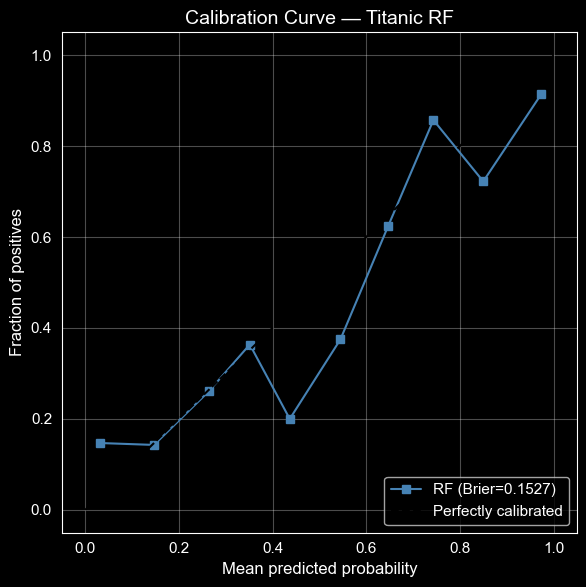

Brier score: 0.1527  (lower is better, 0 = perfect)


In [66]:
# --- Calibration curve and Brier score ---
y_proba_pos = rf_clf.predict_proba(X_test_t)[:, 1]
brier = brier_score_loss(y_test_t, y_proba_pos)

prob_true, prob_pred = calibration_curve(y_test_t, y_proba_pos, n_bins=10)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(prob_pred, prob_true, 's-', label=f'RF (Brier={brier:.4f})', color='steelblue')
ax.plot([0, 1], [0, 1], 'k--', label='Perfectly calibrated')
ax.set_xlabel('Mean predicted probability')
ax.set_ylabel('Fraction of positives')
ax.set_title('Calibration Curve — Titanic RF')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Brier score: {brier:.4f}  (lower is better, 0 = perfect)')

---

## Summary

| Concept | Key equation | Section |
|---------|-------------|--------|
| Surprise | $I(x) = -\log p(x)$ | §2 |
| Shannon entropy | $H(X) = \mathbb{E}[I(X)]$ | §3 |
| Conditional entropy | $H(Y|X) = H(X,Y) - H(X)$ | §4 |
| Mutual information | $I(X;Y) = H(X) + H(Y) - H(X,Y)$ | §5 |
| KL divergence | $D_{\text{KL}}(P\|Q) = \sum p \log(p/q)$ | §6 |
| Cross-entropy | $H(P,Q) = H(P) + D_{\text{KL}}(P\|Q)$ | §7 |
| Information gain | $\text{IG} = H(Y) - H(Y|X)$ | §8 |
| SHAP | Shapley values: fair attribution | §11 |
| LIME | Local linear approximation | §12 |

### Further reading

- Cover & Thomas, *Elements of Information Theory* (2nd ed.)
- Molnar, *Interpretable Machine Learning* (christophm.github.io/interpretable-ml-book/)
- Lundberg & Lee, *A Unified Approach to Interpreting Model Predictions* (NeurIPS 2017)